<p style="text-align:center"> 
    <a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/" target="_blank"> 
    <img src="../assets/logo.png" width="200" alt="Flavio Aguirre Logo"> 
    </a>
</p>

<h1 align="center"><strong>Weather Wise – 03 · Feature Engineering</strong></h1>
<hr>

In this notebook we take the **clean, localized dataset** created in the previous step and:

- Define features (`X`) and target (`y`).
- Check the **class balance** of the prediction target.
- Engineer additional **meteorological features** inspired by domain knowledge.
- Inspect correlations between numerical variables.
- Save the **feature–engineered dataset** for modeling.

The goal is to provide a richer and more informative feature space for the subsequent modeling step.

In [13]:
## Feature engineering

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [14]:
# Load the cleaned dataset from the previous step
input_path = "../data/processed/weatherAUS-data-clean.csv"
df = pd.read_csv(input_path)

print(f"Data loaded from {input_path}")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

df.head()

Data loaded from ../data/processed/weatherAUS-data-clean.csv
Shape: 7557 rows x 23 columns


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday,Season
0,MelbourneAirport,11.2,19.9,0.0,5.6,8.8,SW,69.0,W,SW,...,37.0,1005.1,1006.4,7.0,7.0,15.9,18.1,No,Yes,Summer
1,MelbourneAirport,7.8,17.8,1.2,7.2,12.9,SSE,56.0,SW,SSE,...,43.0,1018.0,1019.3,6.0,7.0,12.5,15.8,Yes,No,Summer
2,MelbourneAirport,6.3,21.1,0.0,6.2,10.5,SSE,31.0,E,S,...,35.0,1020.8,1017.6,1.0,7.0,13.4,19.6,No,No,Summer
3,MelbourneAirport,8.1,29.2,0.0,6.4,12.5,SSE,35.0,NE,SSE,...,23.0,1016.2,1012.8,5.0,4.0,16.0,28.2,No,No,Summer
4,MelbourneAirport,9.7,29.0,0.0,7.4,12.3,SE,33.0,SW,SSE,...,31.0,1011.9,1010.3,6.0,2.0,19.4,27.1,No,No,Summer


## 1. Define features and target

Our current target is `RainToday` (redefined in the previous notebook to avoid leakage).  
We start by splitting the data into:

- `X`: feature matrix (all columns except the target),
- `y`: target vector (`RainToday`).

In [6]:
# Define feature matrix X and target vector y
X = df.drop(columns="RainToday", axis=1)
y = df["RainToday"]

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")

Feature matrix X shape: (7557, 22)
Target vector y shape: (7557,)


## 2. Quick look at target balance

Before adding new features, we briefly inspect how balanced the target is.  
A heavily imbalanced target would require special care (e.g. class weights, resampling).

In [7]:
y.value_counts(normalize=True)

RainToday
No     0.763001
Yes    0.236999
Name: proportion, dtype: float64

With these proportions we can see:

- How frequently it rains (according to our definition of `RainToday`) in the Melbourne area.
- If we naïvely **assumed "no rain" every day**, we would be correct roughly **76%** of the time (the majority class).
- The dataset is **somewhat imbalanced** (around 3:1), but not extremely so.  
  For a first baseline we can proceed without resampling, while being careful to look beyond accuracy.

> Note: In later iterations, especially if the business cares more about missing rainy days
> (false negatives), we may:
> - use class weights,
> - apply resampling techniques,
> - or optimize specifically for recall/precision on the "rain" class.

In [8]:
# Differences between temperatures
df["TempDiff"] = df["MaxTemp"] - df["MinTemp"]
df["TempChange"] = df["Temp3pm"] - df["Temp9am"]

# Pressure difference
df["PressureDiff"] = df["Pressure3pm"] - df["Pressure9am"]

# Humidity difference
df["HumidityDiff"] = df["Humidity3pm"] - df["Humidity9am"]

# Wind speed difference
df["WindSpeedDiff"] = df["WindSpeed3pm"] - df["WindSpeed9am"]

# Daily averages
df["AvgHumidity"] = df[["Humidity9am", "Humidity3pm"]].mean(axis=1)
df["AvgTemp"] = df[["Temp9am", "Temp3pm"]].mean(axis=1)

# Climate interaction: rainfall relative to available sunshine
df["RainfallPerSunshine"] = df["Rainfall"] / (df["Sunshine"] + 0.1)  # avoid division by zero

In [9]:
n_original_features = X.shape[1]
n_new_features = df.shape[1] - n_original_features - 1  # -1 for target (RainToday)
print(f"Engineered {n_new_features} new features.")
print(f"Total feature count (including categorical columns): {df.shape[1] - 1} (excluding target)")

Engineered 8 new features.
Total feature count (including categorical columns): 30 (excluding target)


We have extended our feature space with variables that describe:

- **Intra–day dynamics** (morning vs afternoon temperature, humidity, wind).
- **Overall daily conditions** (average temperature and humidity).
- A simple **interaction** between rainfall and sunshine.

These engineered features are candidates to improve the model's ability to distinguish rainy vs non–rainy days.

## 4. Correlation analysis (numerical features only)

Next, we look at the **correlation matrix** for numerical variables:

- High correlations can indicate **redundant features**.
- We also verify that our engineered variables behave as expected (e.g. `AvgTemp` correlates strongly with `Temp3pm` / `Temp9am`).

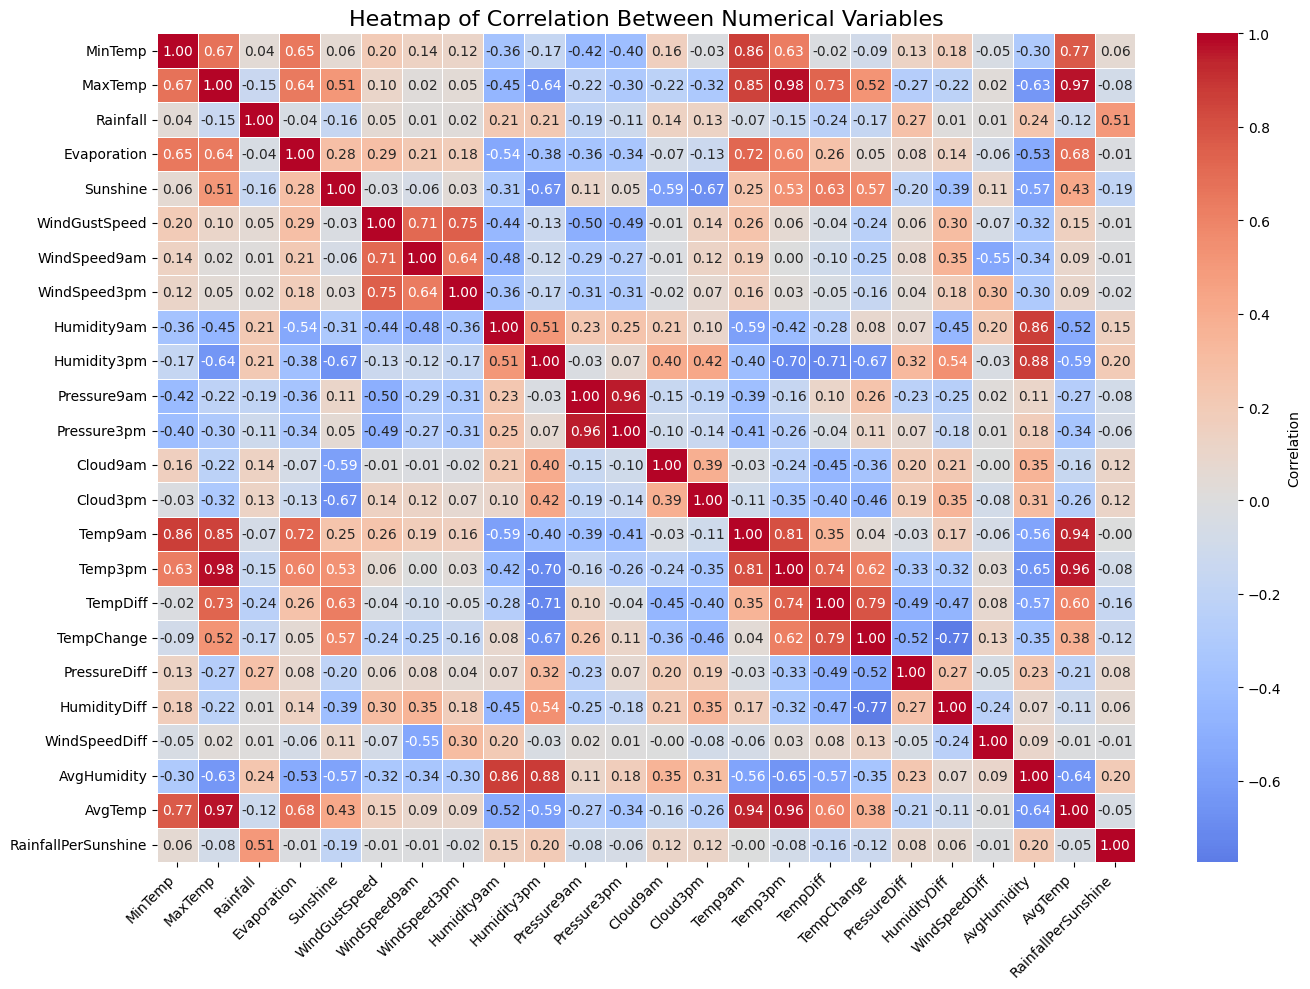

Correlation heatmap saved to: ../reports/figures/heatmap-correlation-between-variables.png


In [11]:
# Correlation matrix for numerical variables only
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)
plt.title("Heatmap of Correlation Between Numerical Variables", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

fig_dir = "../reports/figures/"
os.makedirs(fig_dir, exist_ok=True)
fig_path = os.path.join(fig_dir, "heatmap-correlation-between-variables.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"Correlation heatmap saved to: {fig_path}")

This correlation heatmap helps us validate that our engineered features:

- Are consistent with the underlying physical relationships (e.g. temperature differences and averages),
- Do not all collapse into a single redundant signal.

Later, during modeling, we may decide to drop some highly correlated features if they do not provide additional value.

## 5. Save feature–engineered dataset

We now save the updated dataset (with engineered features) under `data/processed/`  
to be used in the modeling notebook.

We also export the correlation matrix to a CSV file for further inspection if needed.

In [12]:
output_data_path = "../data/processed/weatherAUS-data-engineered.csv"
output_corr_path = "../data/processed/weatherAUS-correlation-matrix.csv"

df.to_csv(output_data_path, index=False)
corr.to_csv(output_corr_path)

print(f"Feature-engineered data saved to: {output_data_path}")
print(f"Correlation matrix saved to:     {output_corr_path}")

Feature-engineered data saved to: ../data/processed/weatherAUS-data-engineered.csv
Correlation matrix saved to:     ../data/processed/weatherAUS-correlation-matrix.csv


At this point, we have:

- A cleaned, localized dataset (Melbourne area),
- Additional meteorological features derived from domain intuition,
- A view of linear relationships between numerical variables.

We are now ready to move on to **modeling**, where we will:

- Encode categorical variables,
- Split the data into train/test sets,
- Train and evaluate classification models.


<hr>

## Author

<a href="https://www.linkedin.com/in/flavio-aguirre-12784a252/">**Flavio Aguirre**</a>
<br>
<a href="https://coursera.org/share/e27ae5af81b56f99a2aa85289b7cdd04">***Data Scientist***</a>

<br>